# A-RQS Decode Speed Scaling Analysis

**Date:** 2026-03-30

Measures how decode (inverse) time scales with embedding dimension D for the
`SplineAutoregressiveEncoder` (A-RQS) vs `CouplingEncoder` with spline coupling (C-RQS).

The autoregressive inverse is O(D) sequential MADE passes per layer, while coupling
is O(1) per layer. This notebook quantifies the actual wall-clock cost.

In [1]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt

from JacobianODE.fnn.coupling_flows import SplineAutoregressiveEncoder, CouplingEncoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA A100 80GB PCIe


In [2]:
# --- Configuration ---
DIMS = [5, 10, 15, 20, 30, 40, 50, 75, 100]
BATCH_SIZE = 32
SEQ_LEN = 50
N_LAYERS = 4
HIDDEN_DIM = 128
N_HIDDEN_LAYERS = 2
NUM_BINS = 8
WARMUP_ITERS = 3
TIMING_ITERS = 10

In [3]:
def time_fn(fn, warmup=WARMUP_ITERS, iters=TIMING_ITERS):
    """Time a function with CUDA synchronization."""
    for _ in range(warmup):
        fn()
    if device.type == 'cuda':
        torch.cuda.synchronize()
    times = []
    for _ in range(iters):
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        fn()
        if device.type == 'cuda':
            torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)
    return np.mean(times), np.std(times)

In [4]:
results = {
    'dims': [],
    'ar_encode_mean': [], 'ar_encode_std': [],
    'ar_decode_mean': [], 'ar_decode_std': [],
    'cp_encode_mean': [], 'cp_encode_std': [],
    'cp_decode_mean': [], 'cp_decode_std': [],
}

for D in DIMS:
    print(f'D={D:3d} ... ', end='', flush=True)

    # Build encoders
    ar_enc = SplineAutoregressiveEncoder(
        n_input=D, n_layers=N_LAYERS, hidden_dim=HIDDEN_DIM,
        n_hidden_layers=N_HIDDEN_LAYERS, num_bins=NUM_BINS,
        use_actnorm=False, zero_init=True,
    ).to(device).eval()

    cp_enc = CouplingEncoder(
        n_input=D, n_coupling_layers=N_LAYERS, coupling_type='spline',
        hidden_dim=HIDDEN_DIM, n_hidden_layers=N_HIDDEN_LAYERS,
        num_bins=NUM_BINS, use_actnorm=False, zero_init=True,
    ).to(device).eval()

    x = torch.randn(BATCH_SIZE, SEQ_LEN, D, device=device)

    with torch.no_grad():
        z_ar = ar_enc.encode(x)
        z_cp = cp_enc.encode(x)

        # Time encode
        ar_enc_t = time_fn(lambda: ar_enc.encode(x))
        cp_enc_t = time_fn(lambda: cp_enc.encode(x))

        # Time decode
        ar_dec_t = time_fn(lambda: ar_enc.decode(z_ar))
        cp_dec_t = time_fn(lambda: cp_enc.decode(z_cp))

    results['dims'].append(D)
    results['ar_encode_mean'].append(ar_enc_t[0])
    results['ar_encode_std'].append(ar_enc_t[1])
    results['ar_decode_mean'].append(ar_dec_t[0])
    results['ar_decode_std'].append(ar_dec_t[1])
    results['cp_encode_mean'].append(cp_enc_t[0])
    results['cp_encode_std'].append(cp_enc_t[1])
    results['cp_decode_mean'].append(cp_dec_t[0])
    results['cp_decode_std'].append(cp_dec_t[1])

    print(f'AR enc={ar_enc_t[0]*1e3:.1f}ms  dec={ar_dec_t[0]*1e3:.1f}ms | '
          f'CP enc={cp_enc_t[0]*1e3:.1f}ms  dec={cp_dec_t[0]*1e3:.1f}ms | '
          f'decode ratio={ar_dec_t[0]/cp_dec_t[0]:.1f}x')

    del ar_enc, cp_enc, x, z_ar, z_cp
    torch.cuda.empty_cache() if device.type == 'cuda' else None

print('\nDone.')

D=  5 ... 

AR enc=4.6ms  dec=26.3ms | CP enc=5.7ms  dec=5.4ms | decode ratio=4.9x
D= 10 ... 

AR enc=4.6ms  dec=52.2ms | CP enc=4.7ms  dec=5.2ms | decode ratio=10.1x
D= 15 ... 

AR enc=4.5ms  dec=82.4ms | CP enc=4.8ms  dec=5.4ms | decode ratio=15.3x
D= 20 ... 

AR enc=4.7ms  dec=112.9ms | CP enc=4.6ms  dec=5.2ms | decode ratio=21.6x
D= 30 ... 

AR enc=5.7ms  dec=161.7ms | CP enc=6.9ms  dec=5.2ms | decode ratio=30.9x
D= 40 ... 

AR enc=7.0ms  dec=212.6ms | CP enc=4.7ms  dec=5.2ms | decode ratio=40.9x
D= 50 ... 

AR enc=8.4ms  dec=286.5ms | CP enc=5.0ms  dec=9.5ms | decode ratio=30.3x
D= 75 ... 

AR enc=11.8ms  dec=400.2ms | CP enc=6.8ms  dec=7.0ms | decode ratio=57.1x
D=100 ... 

AR enc=15.2ms  dec=563.7ms | CP enc=8.4ms  dec=8.6ms | decode ratio=65.4x

Done.


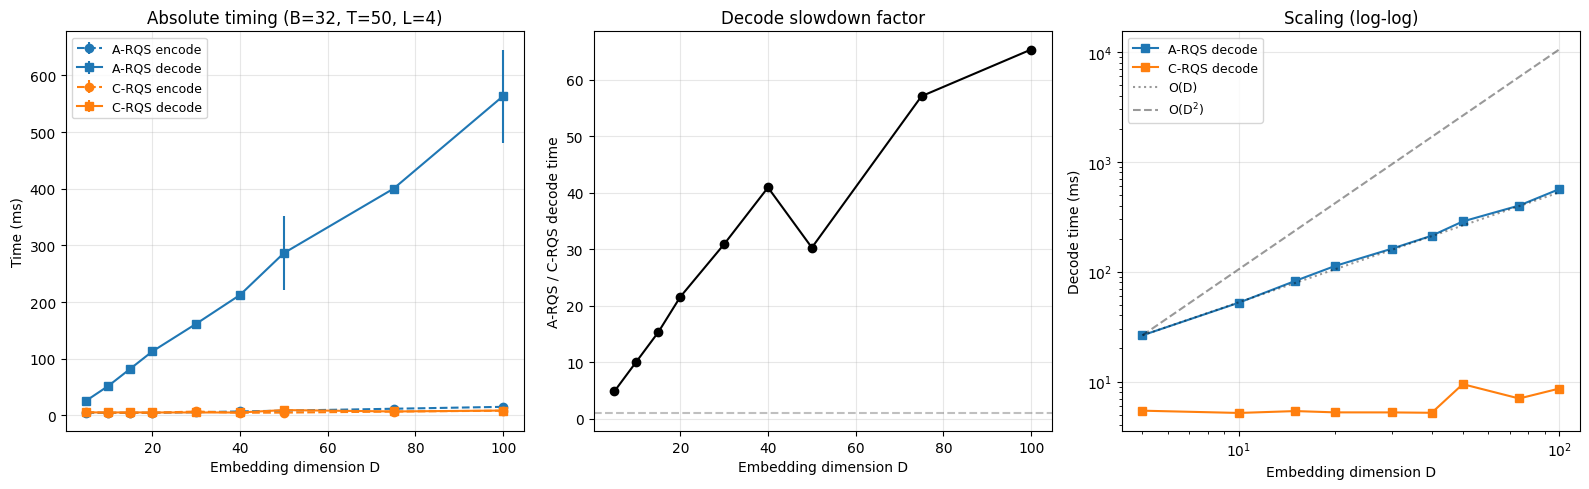

Saved: _sandbox/arqs_decode_scaling.png


In [5]:
dims = np.array(results['dims'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: Absolute times ---
ax = axes[0]
ax.errorbar(dims, np.array(results['ar_encode_mean'])*1e3,
            yerr=np.array(results['ar_encode_std'])*1e3,
            marker='o', label='A-RQS encode', color='C0', ls='--')
ax.errorbar(dims, np.array(results['ar_decode_mean'])*1e3,
            yerr=np.array(results['ar_decode_std'])*1e3,
            marker='s', label='A-RQS decode', color='C0')
ax.errorbar(dims, np.array(results['cp_encode_mean'])*1e3,
            yerr=np.array(results['cp_encode_std'])*1e3,
            marker='o', label='C-RQS encode', color='C1', ls='--')
ax.errorbar(dims, np.array(results['cp_decode_mean'])*1e3,
            yerr=np.array(results['cp_decode_std'])*1e3,
            marker='s', label='C-RQS decode', color='C1')
ax.set_xlabel('Embedding dimension D')
ax.set_ylabel('Time (ms)')
ax.set_title(f'Absolute timing (B={BATCH_SIZE}, T={SEQ_LEN}, L={N_LAYERS})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Panel 2: Decode ratio ---
ax = axes[1]
ratio = np.array(results['ar_decode_mean']) / np.array(results['cp_decode_mean'])
ax.plot(dims, ratio, 'ko-', markersize=6)
ax.axhline(1, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Embedding dimension D')
ax.set_ylabel('A-RQS / C-RQS decode time')
ax.set_title('Decode slowdown factor')
ax.grid(True, alpha=0.3)

# --- Panel 3: Log-log to check scaling ---
ax = axes[2]
ax.loglog(dims, np.array(results['ar_decode_mean'])*1e3, 'C0s-', label='A-RQS decode')
ax.loglog(dims, np.array(results['cp_decode_mean'])*1e3, 'C1s-', label='C-RQS decode')
# Reference lines
d0, t0 = dims[0], results['ar_decode_mean'][0]*1e3
ax.loglog(dims, t0 * (dims/d0)**1, 'k:', alpha=0.4, label='O(D)')
ax.loglog(dims, t0 * (dims/d0)**2, 'k--', alpha=0.4, label='O(D$^2$)')
ax.set_xlabel('Embedding dimension D')
ax.set_ylabel('Decode time (ms)')
ax.set_title('Scaling (log-log)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('_sandbox/arqs_decode_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: _sandbox/arqs_decode_scaling.png')

In [6]:
# --- Summary table ---
print(f"{'D':>5}  {'AR enc':>10}  {'AR dec':>10}  {'CP enc':>10}  {'CP dec':>10}  {'dec ratio':>10}")
print('-' * 65)
for i, D in enumerate(results['dims']):
    ar_enc = results['ar_encode_mean'][i] * 1e3
    ar_dec = results['ar_decode_mean'][i] * 1e3
    cp_enc = results['cp_encode_mean'][i] * 1e3
    cp_dec = results['cp_decode_mean'][i] * 1e3
    ratio = ar_dec / cp_dec
    print(f'{D:5d}  {ar_enc:8.2f}ms  {ar_dec:8.2f}ms  {cp_enc:8.2f}ms  {cp_dec:8.2f}ms  {ratio:8.1f}x')

    D      AR enc      AR dec      CP enc      CP dec   dec ratio
-----------------------------------------------------------------
    5      4.60ms     26.34ms      5.71ms      5.43ms       4.9x
   10      4.61ms     52.21ms      4.75ms      5.17ms      10.1x
   15      4.53ms     82.44ms      4.77ms      5.38ms      15.3x
   20      4.68ms    112.92ms      4.64ms      5.24ms      21.6x
   30      5.68ms    161.71ms      6.93ms      5.23ms      30.9x
   40      7.03ms    212.63ms      4.71ms      5.19ms      40.9x
   50      8.44ms    286.53ms      4.96ms      9.46ms      30.3x
   75     11.78ms    400.19ms      6.76ms      7.01ms      57.1x
  100     15.18ms    563.75ms      8.38ms      8.62ms      65.4x
